This project analyzes Senegal’s macroeconomic indicators using World Bank data.

Step 1: Data collection via API  
Step 2: Data cleaning (missing values + outlier detection)  

In [64]:
# First, we will import sll the libraries we will need for this project

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import json

In [65]:
# We will now create a function to get the data from the World Bank API. This function will take in the indicator code and the country code as arguments and will return a pandas dataframe with the data.

def get_data(indicator_code, country_code, start_year, end_year):
    url = f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator_code}"
    params = {
        "format":   "json",
        "date":     f"{start_year}:{end_year}",
        "per_page": 1000
    }

    response = requests.get(url, params=params)
    data = response.json()

    df = pd.DataFrame(data[1])
    df = df[["date", "value"]]
    df.rename(columns={"value": "GDP (in billions of USD)"}, inplace=True)
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    return df


In [66]:
# Next, we will get the GDP data for Senegal from 2000 to 2020. The indicator code for GDP is 'NY.GDP.MKTP.CD' and the country code for Senegal is 'SN'.
gdp_senegal_2000_2020 = get_data('NY.GDP.MKTP.CD', 'SN', 2000, 2025)
print(gdp_senegal_2000_2020.head())


            GDP (in billions of USD)
date                                
2025-01-01                       NaN
2024-01-01              3.280806e+10
2023-01-01              3.069633e+10
2022-01-01              2.778333e+10
2021-01-01              2.752078e+10


In [88]:
# For the next step, we will create a function that will clean the data by checking for missing values and outliers. We will also convert the data to a more usable format if necessary.
def clean_data(df):
    # Check for missing values
    print(df.isna().sum())
    # Drop missing values
    df = df.dropna()

    # 1. We will delimite the outliers by creating a Q1 and Q3 for the GDP data
    Q1 = df["GDP (in billions of USD)"].quantile(0.25)
    Q3 = df["GDP (in billions of USD)"].quantile(0.75)
    
    # 2. We will calculate the interquartile range (IQR) and use it to filter out the outliers
    IQR = Q3 - Q1

    # 3. we will calculate the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 4. We will now create a column that will say wether the data is an outlier or not
    outliers = df[(df["GDP (in billions of USD)"] < lower_bound) | (df["GDP (in billions of USD)"] > upper_bound)]

    print(f"Data shape after cleaning: {df.shape[0]} rows")
    print(f"Outliers removed: {gdp_senegal_2000_2020.shape[0] - df.shape[0]}")
    return df, outliers



In [87]:
# Let's clean the GDP data for Senegal
gdp_senegal_2000_2020_cleaned, outliers = clean_data(gdp_senegal_2000_2020)
print(gdp_senegal_2000_2020_cleaned.head())


GDP (in billions of USD)    1
dtype: int64
Data shape after cleaning: 25 rows
Outliers removed: 1
            GDP (in billions of USD)
date                                
2024-01-01              3.280806e+10
2023-01-01              3.069633e+10
2022-01-01              2.778333e+10
2021-01-01              2.752078e+10
2020-01-01              2.453051e+10


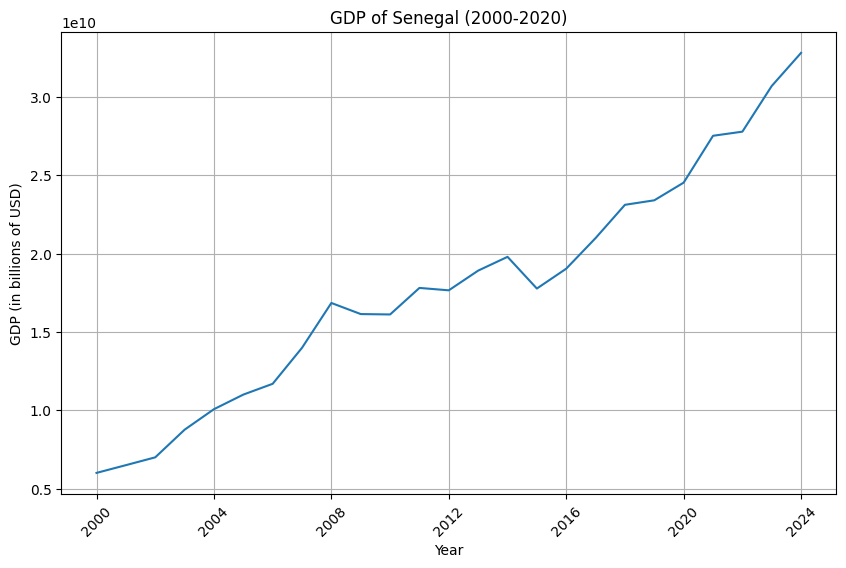

In [69]:
# Now that we have cleaned the data, we will now visualize the GDP data for Senegal from 2000 to 2020 using a line plot.
plt.figure(figsize=(10, 6))
sns.lineplot(data=gdp_senegal_2000_2020_cleaned, x=gdp_senegal_2000_2020_cleaned.index, y="GDP (in billions of USD)")
plt.title("GDP of Senegal (2000-2020)")
plt.xlabel("Year")
plt.ylabel("GDP (in billions of USD)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [74]:
# Now, we save the data in it's respective files
gdp_senegal_2000_2020.to_csv("../data/raw/gdp_raw.csv")

gdp_senegal_2000_2020_cleaned.to_csv("../data/processed/gdp_senegal_2000_2020_cleaned.csv")
